#Nama Proyek Capstone : SinomiAI
###*SinomiAI adalah platform berbasis AI untuk scanning, klasifikasi, dan rekomendasi pengolahan limbah berbasis ekonomi sirkular*

#Anggota Tim : CC26-PSU343
- Riana Shofiatul Khoeriyah ID CDCC222D6X0570
- Mohammad Fahriza Pratama ID CFCC222D6Y1056
- Yildi Andriana ID CDCC222D6Y1231
- Muhammad Irsyad Mustaqim ID CACC222D6Y1363
- Madda Athia Rahman ID CFCC222D6Y2794


#Import Library

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("Eager execution:", tf.executing_eagerly())

TensorFlow version: 2.20.0
Eager execution: True


Pada tahap ini, seluruh library yang dibutuhkan berhasil diimpor dengan baik sehingga environment sudah siap digunakan untuk proses deep learning dan pengolahan data. TensorFlow versi 2.20.0 berjalan normal dengan eager execution aktif, yang menunjukkan bahwa proses eksekusi model dapat dilakukan secara langsung dan lebih mudah untuk debugging. Penggunaan layer seperti Conv2D, MaxPooling2D, dan Dense menunjukkan bahwa model yang akan dibangun menggunakan metode Convolutional Neural Network (CNN) untuk klasifikasi gambar. Selain itu, adanya ImageDataGenerator mengindikasikan bahwa sistem kemungkinan menggunakan augmentasi data untuk meningkatkan performa model dan mengurangi overfitting.


#(Data Wrangling: Gathering Data)

In [17]:
import os
from google.colab import drive

drive.mount('/content/drive')

dataset_dir = '/content/drive/MyDrive/Capstone Project CC26-PSU343/Data Science/Dataset'

if os.path.exists(dataset_dir):
    print("Gathering Data Berhasil: Folder ditemukan.")
    print("Isi folder:", os.listdir(dataset_dir))
else:
    print(f"Error: Path tidak ditemukan. Cek kembali nama folder di Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Gathering Data Berhasil: Folder ditemukan.
Isi folder: ['Anorganik', 'Organik']


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Pada tahap Gathering Data, dilakukan proses integrasi antara Google Colab dan Google Drive untuk mengakses dataset yang digunakan dalam penelitian. Berdasarkan hasil eksekusi program, folder dataset pada direktori `/content/drive/MyDrive/Capstone Project CC26-PSU343/Data Science/Dataset` berhasil ditemukan. Selain itu, sistem menampilkan dua subfolder yang tersedia, yaitu Anorganik dan Organik, yang merepresentasikan kelas data pada dataset klasifikasi sampah. Keberhasilan proses ini menunjukkan bahwa data telah tersimpan dengan struktur yang sesuai dan dapat digunakan sebagai sumber data pada tahapan preprocessing, eksplorasi data, dan pengembangan model machine learning.

#(Data Wrangling: Assessing Data)

In [19]:
import os
from google.colab import drive

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

dataset_dir = '/content/drive/MyDrive/Capstone Project CC26-PSU343/Data Science/Dataset'

if os.path.exists(dataset_dir):
    print("Gathering Data Berhasil: Folder Dataset DBS ditemukan.")
    print("--- Memulai Assessing Data ---")

    categories = os.listdir(dataset_dir)
    for category in categories:
        folder_path = os.path.join(dataset_dir, category)
        if os.path.isdir(folder_path):
            count = len(os.listdir(folder_path))
            print(f"Kategori: {category:15} | Jumlah: {count} gambar")

    print("--- Assessing Selesai ---")
else:
    print(f"Error: Folder tidak ditemukan di {dataset_dir}")

Gathering Data Berhasil: Folder Dataset DBS ditemukan.
--- Memulai Assessing Data ---
Kategori: Anorganik       | Jumlah: 1010 gambar
Kategori: Organik         | Jumlah: 789 gambar
--- Assessing Selesai ---


Tahap Assessing Data bertujuan untuk mengevaluasi struktur dan kelengkapan dataset sebelum dilakukan preprocessing. Berdasarkan hasil pemeriksaan, folder Dataset DBS berhasil diakses dan berisi dua kategori data, yaitu Anorganik dan Organik. Jumlah data pada kategori Anorganik tercatat sebanyak 1.010 citra, sedangkan kategori Organik sebanyak 789 citra. Dengan total 1.799 citra, dataset dinilai telah tersedia dengan baik dan siap digunakan pada tahapan selanjutnya, seperti pembersihan data, augmentasi citra, pembagian data latih dan uji, serta pengembangan model klasifikasi sampah berbasis machine learning atau deep learning.

#(Data Wrangling: Cleaning Data)

In [20]:
import os
import shutil
from PIL import Image

dataset_dir = '/content/drive/MyDrive/Capstone Project CC26-PSU343/Data Science/Dataset'
valid_extensions = ('.jpg', '.jpeg', '.png')

cleaned_corrupt = 0
cleaned_invalid_ext = 0
moved_files = 0

print("--- Memulai Restrukturisasi dan Pembersihan Data ---")

if os.path.exists(dataset_dir):
    categories = os.listdir(dataset_dir)
    for category in categories:
        category_path = os.path.join(dataset_dir, category)

        if os.path.isdir(category_path):
            print(f"\nMemeriksa kategori: {category}")

            for root, dirs, files in os.walk(category_path):
                for file in files:
                    file_path = os.path.join(root, file)

                    if not file.lower().endswith(valid_extensions):
                        print(f"  [DIHAPUS] Bukan gambar valid: {file}")
                        os.remove(file_path)
                        cleaned_invalid_ext += 1
                        continue

                    is_valid = True
                    try:
                        with Image.open(file_path) as img:
                            img.verify()
                    except (IOError, SyntaxError):
                        print(f"  [DIHAPUS] File korup/rusak: {file}")
                        os.remove(file_path)
                        cleaned_corrupt += 1
                        is_valid = False

                    if is_valid and root != category_path:
                        new_file_name = f"{os.path.basename(root)}_{file}"
                        new_file_path = os.path.join(category_path, new_file_name)

                        shutil.move(file_path, new_file_path)
                        moved_files += 1

            for root, dirs, files in os.walk(category_path, topdown=False):
                for dir_name in dirs:
                    dir_path = os.path.join(root, dir_name)
                    if not os.listdir(dir_path):
                        os.rmdir(dir_path)

    print("\n--- Proses Selesai ---")
    print(f"Total gambar dikeluarkan dari sub-folder: {moved_files}")
    print(f"Total file non-gambar dihapus         : {cleaned_invalid_ext}")
    print(f"Total file korup/rusak dihapus        : {cleaned_corrupt}")
    print("Dataset siap dieksekusi oleh ImageDataGenerator!")
else:
    print(f"Error: Direktori tidak ditemukan di {dataset_dir}")

--- Memulai Restrukturisasi dan Pembersihan Data ---

Memeriksa kategori: Anorganik

Memeriksa kategori: Organik
  [DIHAPUS] Bukan gambar valid: Food Organics_412.webp

--- Proses Selesai ---
Total gambar dikeluarkan dari sub-folder: 0
Total file non-gambar dihapus         : 1
Total file korup/rusak dihapus        : 0
Dataset siap dieksekusi oleh ImageDataGenerator!


Tahap Cleaning Data dilakukan untuk memastikan kualitas dan konsistensi dataset sebelum digunakan pada proses pelatihan model. Sistem memvalidasi format file gambar yang terdapat pada setiap kategori dataset, yaitu Anorganik dan Organik, dengan hanya mempertahankan file berformat .jpg, .jpeg, dan .png. Hasil validasi menunjukkan bahwa tidak terdapat citra yang korup atau rusak. Akan tetapi, ditemukan satu file dengan format yang tidak didukung, yaitu .webp, sehingga file tersebut dihapus dari dataset. Tidak ditemukan kebutuhan restrukturisasi data karena tidak ada file yang berada pada sub-folder. Dengan demikian, dataset telah bersih, terorganisasi, dan siap digunakan pada tahap preprocessing serta pelatihan model deep learning menggunakan ImageDataGenerator.

In [21]:
import os

dataset_dir = '/content/drive/MyDrive/Capstone Project CC26-PSU343/Data Science/Dataset'
total_keseluruhan = 0

print("--- Laporan Hasil Akhir Dataset ---")

if os.path.exists(dataset_dir):
    categories = os.listdir(dataset_dir)

    # Mengurutkan nama kategori agar tampilannya rapi secara alfabetis
    categories.sort()

    for category in categories:
        category_path = os.path.join(dataset_dir, category)

        if os.path.isdir(category_path):
            # Menghitung jumlah file di dalam folder kategori
            jumlah_file = len(os.listdir(category_path))
            total_keseluruhan += jumlah_file

            # Format string agar output sejajar dan rapi
            print(f"Kategori: {category:15} | Jumlah Valid: {jumlah_file} gambar")

    print("-" * 50)
    print(f"TOTAL KESELURUHAN DATASET SIAP LATIH : {total_keseluruhan} gambar")
    print("-" * 50)

--- Laporan Hasil Akhir Dataset ---
Kategori: Anorganik       | Jumlah Valid: 1010 gambar
Kategori: Organik         | Jumlah Valid: 788 gambar
--------------------------------------------------
TOTAL KESELURUHAN DATASET SIAP LATIH : 1798 gambar
--------------------------------------------------


Tahap ini merupakan proses verifikasi akhir terhadap dataset setelah seluruh tahapan cleaning data selesai dilaksanakan. Berdasarkan hasil penghitungan, kategori Anorganik memiliki 1.010 citra, sedangkan kategori Organik memiliki 788 citra, sehingga total dataset yang siap digunakan mencapai 1.798 citra. Hasil tersebut menunjukkan bahwa dataset telah berhasil dibersihkan dari file yang tidak sesuai dan tersusun dengan baik sesuai kategori masing-masing. Dataset yang telah tervalidasi ini menjadi dasar untuk tahapan selanjutnya, yaitu preprocessing citra, augmentasi data, pembagian dataset, dan pelatihan model deep learning untuk klasifikasi sampah organik dan anorganik.

#DATA DICTIONARY

In [22]:
print("===================================================")
print(" DATA DICTIONARY - PEMETAAN KELAS DATASET SAMPAH ")
print("===================================================")

def map_to_group(label):
    organic_list = [
        'organik',
        'organic',
        'sampah_basah'
    ]

    if label.lower() in organic_list:
        return 'Organik (Sampah Basah)'
    else:
        return 'Anorganik (Daur Ulang)'

# Pastikan train_generator sudah ada
if 'train_generator' in globals():

    class_indices = train_generator.class_indices

    print(f"{'Nama Kelas':15} {'Index':10} {'Kelompok'}")
    print("-"*50)

    for name, idx in class_indices.items():
        group = map_to_group(name)

        print(
            f"{name:15} {idx:<10} {group}"
        )

else:
    print("train_generator belum dibuat.")
    print("Jalankan cell ImageDataGenerator terlebih dahulu.")

 DATA DICTIONARY - PEMETAAN KELAS DATASET SAMPAH 
Nama Kelas      Index      Kelompok
--------------------------------------------------
Anorganik       0          Anorganik (Daur Ulang)
Organik         1          Organik (Sampah Basah)


Dataset terdiri dari dua kategori utama, yaitu Anorganik dan Organik. Sistem secara otomatis memberikan label numerik menggunakan mekanisme class_indices dari TensorFlow/Keras, di mana kelas Anorganik direpresentasikan dengan label 0 dan kelas Organik direpresentasikan dengan label 1.

Label numerik tersebut digunakan sebagai target klasifikasi selama proses pelatihan model. Selain itu, setiap kelas dipetakan ke kelompok bisnis yang lebih mudah dipahami oleh pengguna, yaitu Anorganik (Daur Ulang) dan Organik (Sampah Basah). Pemetaan ini membantu proses interpretasi hasil prediksi serta mendukung implementasi sistem pengelolaan sampah berbasis kecerdasan buatan.

#EDA

1. Melakukan Refresh Memori Generator...
Found 1439 images belonging to 2 classes.

2. Menyiapkan Visualisasi EDA...
 Inspeksi Visual (EDA): Sampel Batch Generator Latih  


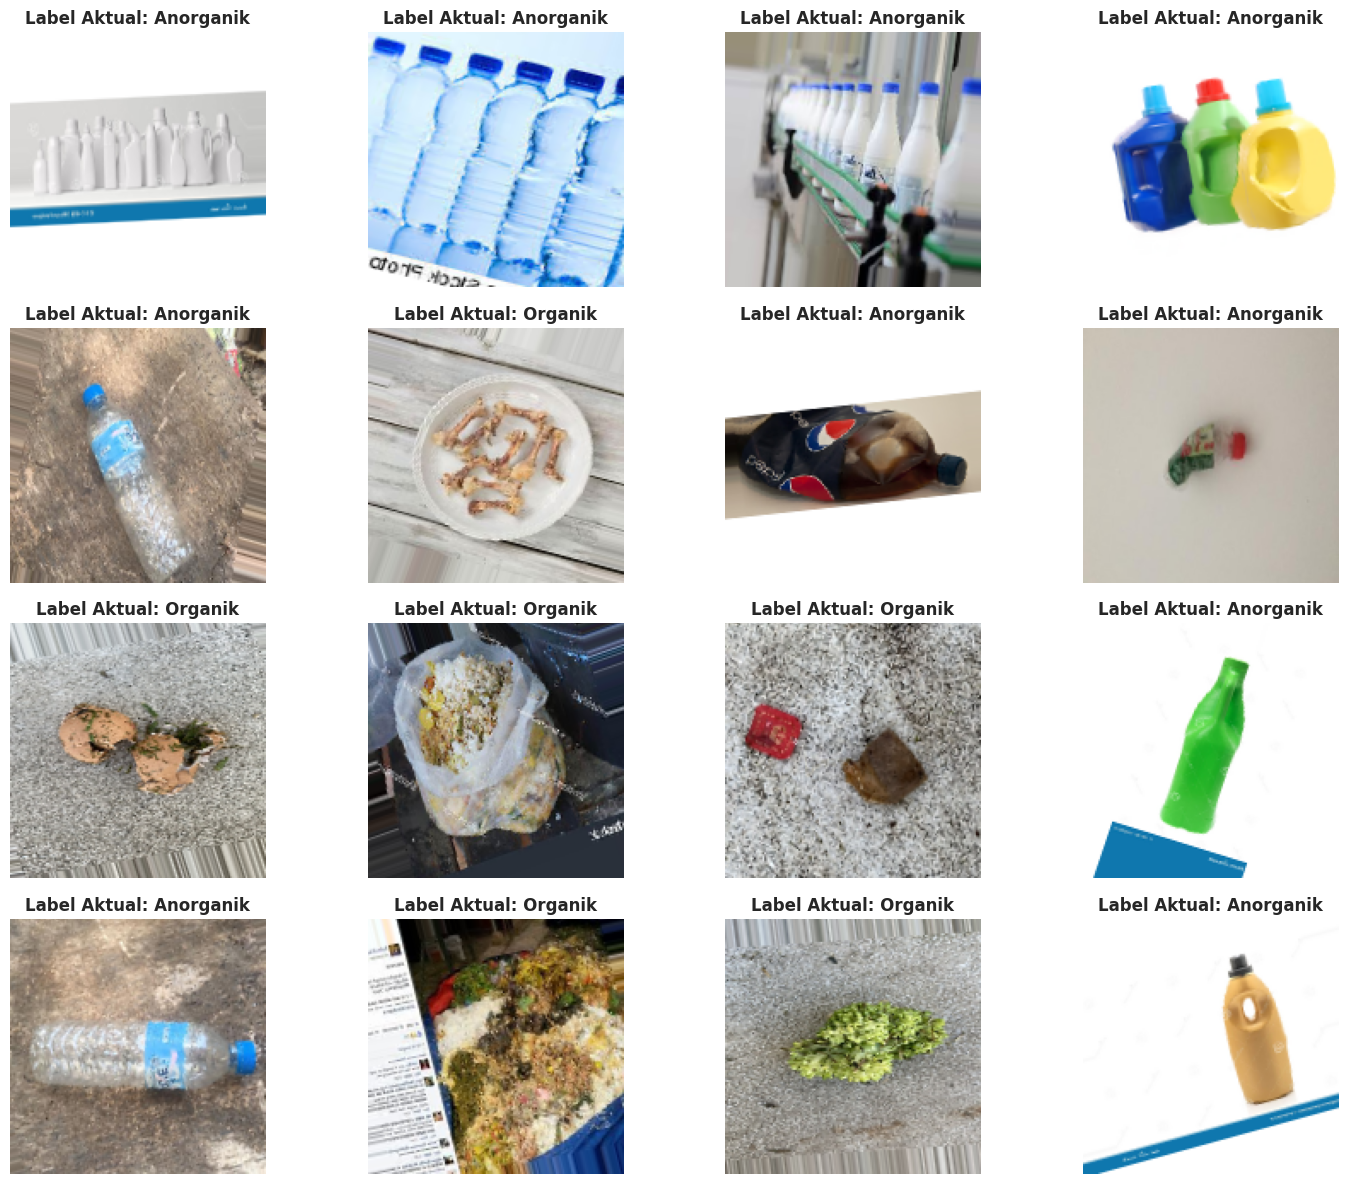

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("1. Melakukan Refresh Memori Generator...")
dataset_dir = '/content/drive/MyDrive/Capstone Project CC26-PSU343/Data Science/Dataset'

# Inisialisasi ulang datagen (pastikan variabel tidak ada yang tertinggal)
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    shear_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest',
    validation_split=0.2
)

# Memaksa scan ulang folder
train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

print("\n2. Menyiapkan Visualisasi EDA...")
labels_map = {v: k for k, v in train_generator.class_indices.items()}

plt.figure(figsize=(15, 12))

# Mengambil batch baru dengan peta folder yang sudah di-refresh
images, labels = next(train_generator)

print("======================================================")
print(" Inspeksi Visual (EDA): Sampel Batch Generator Latih  ")
print("======================================================")

for i in range(min(16, len(images))):
    plt.subplot(4, 4, i+1)
    plt.imshow(images[i])

    idx = np.argmax(labels[i])
    class_name = labels_map[idx]

    plt.title(f"Label Aktual: {class_name}", fontsize=12, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

Pada tahap Exploratory Data Analysis (EDA), dilakukan eksplorasi awal untuk memahami karakteristik dataset citra sampah yang akan digunakan dalam proses pelatihan model klasifikasi. Tahap ini bertujuan untuk memastikan bahwa data telah berhasil dimuat dengan benar serta memberikan gambaran mengenai struktur dataset yang akan dipelajari oleh model.

Berdasarkan hasil proses pemuatan data menggunakan generator TensorFlow/Keras, ditemukan sebanyak 1.439 gambar yang terbagi ke dalam 2 kelas, yaitu Anorganik dan Organik. Hasil ini menunjukkan bahwa seluruh gambar pada dataset berhasil dibaca dan siap digunakan pada tahapan analisis maupun pelatihan model.

## Defining Business Questions
1. Bagaimana distribusi jumlah gambar untuk setiap kategori sampah (Organik vs. Anorganik beserta sub-kelasnya) dalam dataset yang digunakan?
2. Apakah dataset memiliki variasi visual yang cukup dari sisi resolusi dan rasio aspek untuk melatih model Computer Vision secara objektif dan generalisable?
3. Kategori mana yang memiliki jumlah data yang paling dominan atau paling sedikit yang berpotensi menyebabkan ketidakseimbangan data (data imbalance) dan bagaimana dampaknya terhadap performa model?


--- Insight Struktur Data ---
 Kategori  Jumlah_Gambar
Anorganik           1010
  Organik            788




/tmp/ipykernel_2112/3660130163.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eda, x="Kategori", y="Jumlah_Gambar", palette="viridis")


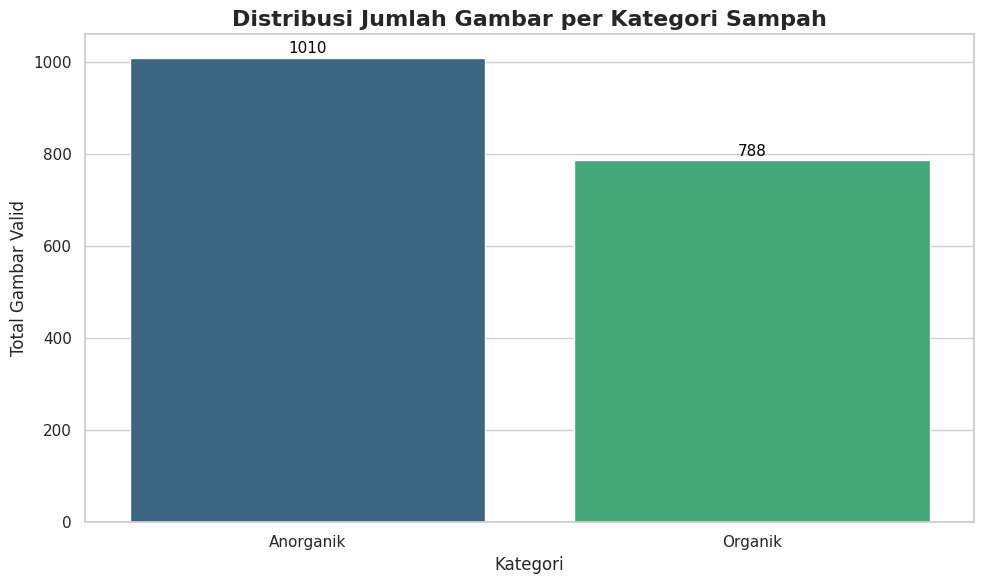

In [24]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Gunakan direktori utama yang sudah kita pastikan kebenarannya
dataset_dir = '/content/drive/MyDrive/Capstone Project CC26-PSU343/Data Science/Dataset'

data_info = []

# Menggunakan dataset_dir, bukan train_dir
for category in os.listdir(dataset_dir):
    path = os.path.join(dataset_dir, category)
    if os.path.isdir(path):
        data_info.append({
            "Kategori": category,
            "Jumlah_Gambar": len(os.listdir(path))
        })

# Membuat DataFrame menggunakan Pandas
df_eda = pd.DataFrame(data_info)

print("--- Insight Struktur Data ---")
print(df_eda.sort_values(by="Jumlah_Gambar", ascending=False).to_string(index=False))
print("\n")

# --- Visualisasi Grafik Distribusi Data ---
plt.figure(figsize=(10, 6))

# Menggunakan Seaborn untuk membuat diagram batang yang estetis
sns.barplot(data=df_eda, x="Kategori", y="Jumlah_Gambar", palette="viridis")

# Kostumisasi tampilan plot
plt.title("Distribusi Jumlah Gambar per Kategori Sampah", fontsize=16, fontweight='bold')
plt.xlabel("Kategori", fontsize=12)
plt.ylabel("Total Gambar Valid", fontsize=12)

# Menambahkan angka jumlah tepat di atas setiap batang
for index, row in df_eda.iterrows():
    plt.text(index, row.Jumlah_Gambar + (row.Jumlah_Gambar * 0.01),
             f'{row.Jumlah_Gambar}', color='black', ha="center", fontsize=11)

plt.tight_layout()
plt.show()

Pada visualisasi diagram batang yang dihasilkan, terlihat secara jelas perbandingan distribusi jumlah gambar antara dua kategori dalam dataset. Kategori `Anorganik` mendominasi dengan **1.010 gambar**, sementara kategori `Organik` memiliki **788 gambar**, sehingga total keseluruhan dataset mencapai **1.798 gambar**. Secara visual, perbedaan tinggi kedua batang cukup terlihat namun tidak terlalu ekstrem, yang mengindikasikan bahwa ketidakseimbangan kelas yang terjadi masih berada pada tingkat yang moderat.

Jika dilihat secara proporsional, kategori `Anorganik` menyumbang sekitar **56,2%** dari total data, sedangkan `Organik` menyumbang sekitar **43,8%**. Selisih sekitar **222 gambar** antara kedua kelas ini perlu menjadi perhatian pada saat proses pelatihan model berlangsung. Meskipun tidak separah kasus *imbalance* ekstrem, kondisi ini tetap berpotensi membuat model sedikit lebih condong (*bias*) dalam memprediksi kelas `Anorganik` sebagai kelas mayoritas. Untuk mengantisipasi hal tersebut, beberapa pendekatan dapat dipertimbangkan seperti penggunaan *class weight* saat pelatihan, teknik oversampling pada kelas minoritas, atau memastikan augmentasi data diterapkan secara merata pada kedua kelas.

--- Memindai Dimensi Gambar (Sampling) ---
Pemindaian selesai! Menyiapkan visualisasi...



/tmp/ipykernel_2112/1222377727.py:51: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_dim, x="Aspect Ratio", hue="Kategori",


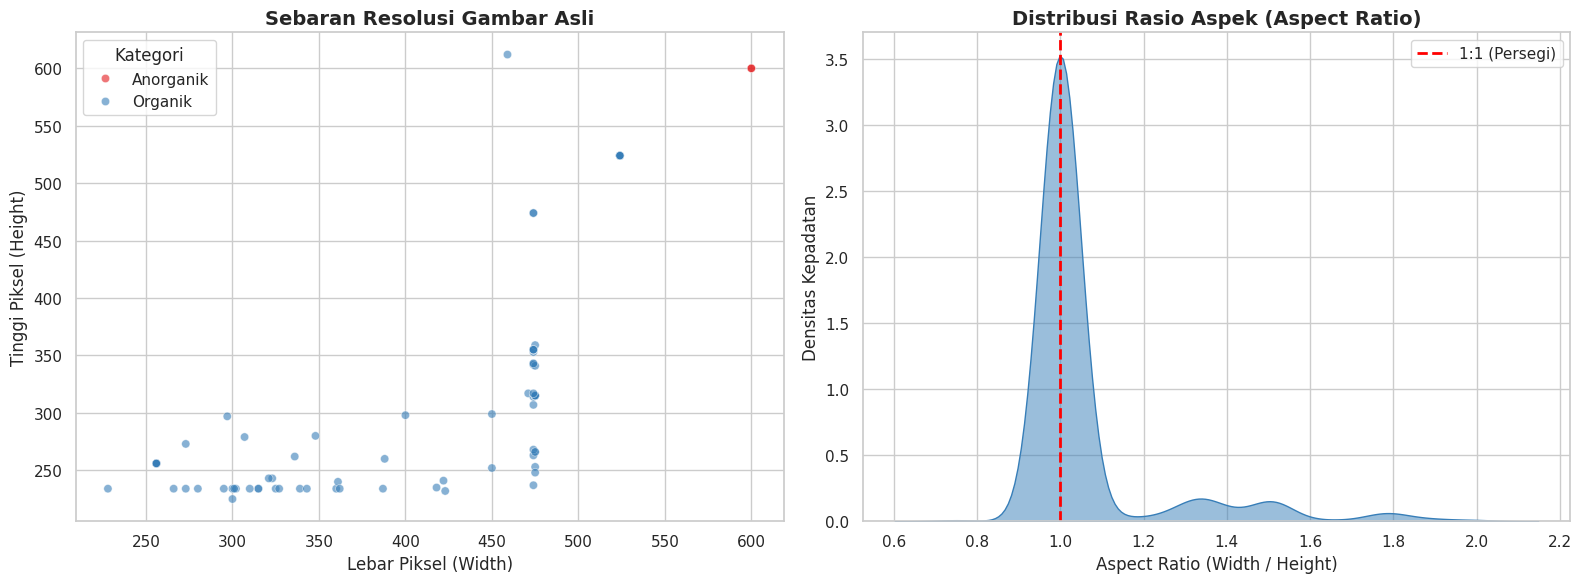

In [25]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

dataset_dir = '/content/drive/MyDrive/Capstone Project CC26-PSU343/Data Science/Dataset'
dim_data = []

print("--- Memindai Dimensi Gambar (Sampling) ---")
# Mengiterasi kategori di dalam dataset
for category in os.listdir(dataset_dir):
    cat_path = os.path.join(dataset_dir, category)
    if os.path.isdir(cat_path):
        files = os.listdir(cat_path)

        # Mengambil maksimal 500 gambar per kategori agar RAM tidak penuh dan proses cepat
        for file in files[:500]:
            file_path = os.path.join(cat_path, file)
            try:
                # Hanya membaca header gambar untuk efisiensi
                with Image.open(file_path) as img:
                    width, height = img.size
                    dim_data.append({
                        "Kategori": category,
                        "Width": width,
                        "Height": height
                    })
            except Exception:
                pass

# Membuat DataFrame
df_dim = pd.DataFrame(dim_data)

# Menghitung Aspect Ratio (Lebar dibagi Tinggi)
df_dim['Aspect Ratio'] = df_dim['Width'] / df_dim['Height']

print("Pemindaian selesai! Menyiapkan visualisasi...\n")

# --- Membuat Visualisasi Ganda (Subplots) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Scatter Plot: Sebaran Resolusi (Width vs Height)
sns.scatterplot(data=df_dim, x="Width", y="Height", hue="Kategori",
                alpha=0.6, palette="Set1", ax=axes[0])
axes[0].set_title("Sebaran Resolusi Gambar Asli", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Lebar Piksel (Width)")
axes[0].set_ylabel("Tinggi Piksel (Height)")

# 2. KDE Plot: Distribusi Aspect Ratio
sns.kdeplot(data=df_dim, x="Aspect Ratio", hue="Kategori",
            fill=True, palette="Set1", ax=axes[1], alpha=0.5)
axes[1].set_title("Distribusi Rasio Aspek (Aspect Ratio)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Aspect Ratio (Width / Height)")
axes[1].set_ylabel("Densitas Kepadatan")
# Menambahkan garis vertikal merah di rasio 1.0 (Bentuk Persegi)
axes[1].axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='1:1 (Persegi)')
axes[1].legend()

plt.tight_layout()
plt.show()

Pada tahap ini, kode digunakan untuk menjawab pertanyaan bisnis kedua mengenai apakah dataset memiliki variasi visual yang cukup untuk melatih model secara objektif. Analisis dilakukan dengan memeriksa dua aspek teknis gambar, yaitu sebaran resolusi asli dan distribusi rasio aspek (*aspect ratio*), menggunakan hingga 500 sampel gambar per kategori dengan bantuan library `PIL` agar proses pembacaan gambar lebih efisien terhadap penggunaan memori. Hasil analisis kemudian divisualisasikan menggunakan dua grafik berdampingan.

Berdasarkan grafik **Sebaran Resolusi Gambar Asli** di sebelah kiri, terlihat bahwa sebagian besar gambar dari kedua kategori berada pada rentang resolusi menengah, khususnya di sekitar lebar 250–500 piksel dan tinggi 230–360 piksel. Kategori `Organik` memiliki jumlah titik yang lebih banyak dan menunjukkan variasi resolusi yang lebih beragam dibandingkan kategori `Anorganik`. Hal ini terlihat dari adanya beberapa gambar `Organik` dengan resolusi cukup tinggi, seperti tinggi gambar yang mencapai lebih dari 600 piksel dan lebar hingga sekitar 520 piksel. Sementara itu, kategori `Anorganik` hanya memiliki sedikit sampel dan cenderung terkonsentrasi pada ukuran tertentu, meskipun terdapat satu gambar dengan resolusi cukup besar di sekitar 600×600 piksel. Kondisi ini menunjukkan bahwa dataset memiliki variasi ukuran gambar, terutama pada kategori `Organik`, sehingga model akan dilatih dengan data yang tidak sepenuhnya seragam.

Pada grafik **Distribusi Rasio Aspek (Aspect Ratio)** di sebelah kanan, terlihat bahwa mayoritas gambar memiliki rasio aspek yang sangat dekat dengan nilai **1:1**, ditandai dengan puncak kepadatan tertinggi tepat di sekitar garis merah putus-putus. Hal ini menunjukkan bahwa sebagian besar gambar berbentuk hampir persegi sehingga proses resize ke ukuran tetap, seperti 150×150 piksel, tidak akan menyebabkan distorsi bentuk yang terlalu besar. Selain itu, terdapat sedikit distribusi tambahan di area rasio sekitar **1,3 hingga 1,6**, yang menandakan adanya beberapa gambar berbentuk *landscape* (lebih lebar daripada tinggi). Namun jumlahnya relatif kecil dibandingkan gambar dengan rasio mendekati persegi.

Secara keseluruhan, hasil analisis menunjukkan bahwa dataset memiliki variasi visual yang cukup baik dari sisi resolusi gambar, terutama pada kategori `Organik`, tetapi tetap mempertahankan konsistensi rasio aspek yang dominan mendekati 1:1. Kondisi ini menguntungkan dalam proses pelatihan model karena gambar tidak terlalu mengalami distorsi saat dilakukan normalisasi ukuran, sekaligus tetap memberikan variasi visual yang cukup agar model dapat belajar secara lebih robust terhadap berbagai kondisi gambar sampah.


--- Menghitung Proporsi Dataset ---


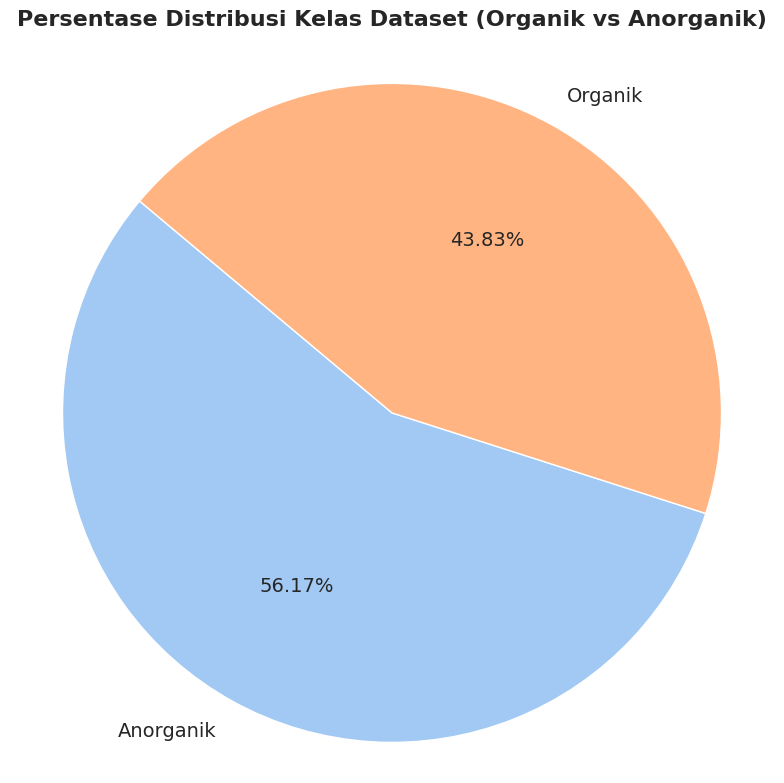

In [31]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset_dir = '/content/drive/MyDrive/Capstone Project CC26-PSU343/Data Science/Dataset'
data_info = []

print("--- Menghitung Proporsi Dataset ---")
# Menghitung jumlah file per direktori kategori
for category in os.listdir(dataset_dir):
    path = os.path.join(dataset_dir, category)
    if os.path.isdir(path):
        data_info.append({
            "Kategori": category,
            "Jumlah": len(os.listdir(path))
        })

# Konversi ke DataFrame
df_pie = pd.DataFrame(data_info)

# --- Membuat Visualisasi Pie Chart ---
plt.figure(figsize=(8, 8))

# Menggunakan palet warna yang profesional (Seaborn color palette)
colors = sns.color_palette('pastel')[0:len(df_pie)]

# Membuat parameter 'explode' untuk memisahkan sedikit potongan kue (agar lebih estetis)
explode = [0.0] * len(df_pie)

# Plotting Pie Chart
plt.pie(df_pie['Jumlah'],
        labels=df_pie['Kategori'],
        colors=colors,
        autopct='%1.2f%%', # Menampilkan persentase hingga 2 angka di belakang koma
        startangle=140,
        explode=explode,
        shadow=False,
        textprops={'fontsize': 14})

# Menambahkan judul
plt.title('Persentase Distribusi Kelas Dataset (Organik vs Anorganik)',
          fontsize=16, fontweight='bold', pad=20)

# Memastikan pie chart berbentuk lingkaran sempurna (tidak lonjong)
plt.axis('equal')

plt.tight_layout()
plt.show()

Pada tahap ini, kode digunakan untuk menjawab pertanyaan bisnis ketiga mengenai kategori mana yang paling dominan dan apakah terdapat potensi ketidakseimbangan data. Pendekatan yang digunakan adalah menghitung jumlah file gambar per folder kategori, lalu memvisualisasikannya dalam bentuk *pie chart* menggunakan `matplotlib` dengan sentuhan estetika dari palet warna Seaborn dan efek *explode* untuk memisahkan tiap irisan secara visual.

Dari diagram lingkaran yang dihasilkan, terlihat bahwa kategori `Anorganik` menjadi kelas yang paling dominan dengan proporsi sebesar **56,17%** (1.010 gambar), sementara kategori `Organik` berada di posisi lebih sedikit dengan **43,83%** (788 gambar) dari total keseluruhan 1.798 data. Selisih sekitar **12,3 poin persentase** antara kedua kelas ini mengonfirmasi adanya ketidakseimbangan data, meskipun masih tergolong dalam kategori *mild imbalance* dan belum sampai pada tahap yang kritis.

Kondisi ini tetap perlu ditangani secara cermat karena model yang dilatih pada data tidak seimbang cenderung lebih terbiasa mengenali pola dari kelas mayoritas, dalam hal ini `Anorganik`, sehingga performanya pada kelas `Organik` berpotensi lebih lemah. Untuk mengatasinya, beberapa strategi yang dapat diterapkan antara lain penggunaan parameter `class_weight='balanced'` saat kompilasi model, penambahan data augmentasi yang lebih agresif pada kelas `Organik`, atau evaluasi model menggunakan metrik yang lebih sensitif terhadap imbalance seperti *F1-Score* dan *Recall* per kelas, bukan hanya akurasi secara keseluruhan.

--- Memindai Sub-Kelas Dataset ---


/tmp/ipykernel_2112/1683983829.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


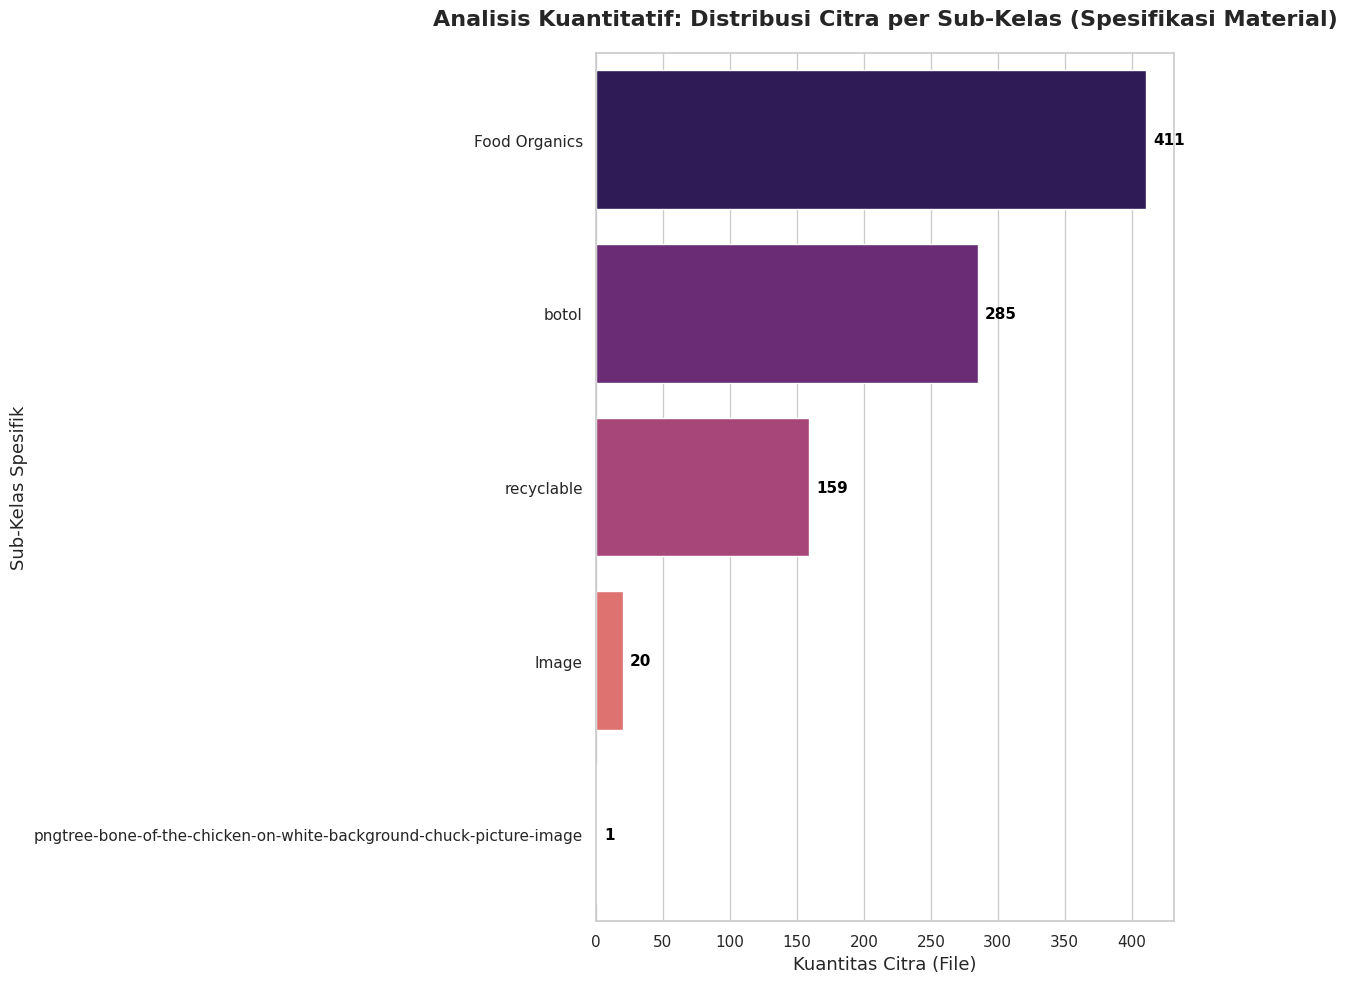

In [27]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dataset_dir = '/content/drive/MyDrive/Capstone Project CC26-PSU343/Data Science/Dataset'
subclass_data = {}

print("--- Memindai Sub-Kelas Dataset ---")

for category in os.listdir(dataset_dir):
    cat_path = os.path.join(dataset_dir, category)
    if os.path.isdir(cat_path):
        for item in os.listdir(cat_path):
            item_path = os.path.join(cat_path, item)

            # Skenario 1: Jika struktur masih bertingkat (ada sub-folder seperti 'Kayu')
            if os.path.isdir(item_path):
                subclass = item
                count = len(os.listdir(item_path))
                subclass_data[subclass] = subclass_data.get(subclass, 0) + count

            # Skenario 2: Jika data sudah di-flatten (gambar menyatu dengan awalan nama sub-kelas)
            elif os.path.isfile(item_path):
                # Ekstrak nama sub-kelas sebelum tanda garis bawah '_' pertama
                if '_' in item:
                    subclass = item.split('_')[0]
                    subclass_data[subclass] = subclass_data.get(subclass, 0) + 1
                else:
                    subclass = "Tidak Teridentifikasi"
                    subclass_data[subclass] = subclass_data.get(subclass, 0) + 1

# Mengubah dictionary menjadi Pandas DataFrame dan mengurutkannya
df_subclass = pd.DataFrame(list(subclass_data.items()), columns=["Sub_Kelas", "Jumlah_Gambar"])
df_subclass = df_subclass.sort_values(by="Jumlah_Gambar", ascending=False)

# Menghapus kategori "Tidak Teridentifikasi" jika jumlahnya 0 atau tidak relevan
df_subclass = df_subclass[df_subclass["Sub_Kelas"] != "Tidak Teridentifikasi"]

# --- Visualisasi Horizontal Bar Chart ---
plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

# Menggunakan orientasi horizontal (x=Jumlah, y=Sub_Kelas)
ax = sns.barplot(
    data=df_subclass,
    x="Jumlah_Gambar",
    y="Sub_Kelas",
    palette="magma" # Palet warna yang elegan
)

plt.title("Analisis Kuantitatif: Distribusi Citra per Sub-Kelas (Spesifikasi Material)",
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Kuantitas Citra (File)", fontsize=13)
plt.ylabel("Sub-Kelas Spesifik", fontsize=13)

# Menambahkan anotasi angka di ujung setiap batang
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width)}',
        (width, p.get_y() + p.get_height() / 2.),
        ha='left',
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()

Pada tahap ini, kode digunakan untuk menganalisis distribusi jumlah citra pada setiap sub-kelas dataset berdasarkan spesifikasi material sampah. Proses analisis dilakukan dengan memindai struktur dataset untuk mengidentifikasi nama sub-kelas beserta jumlah gambar yang dimiliki masing-masing sub-kelas. Hasil perhitungan kemudian divisualisasikan menggunakan *horizontal bar chart* agar perbandingan jumlah data antar sub-kelas dapat terlihat lebih jelas.

Berdasarkan grafik yang dihasilkan, terlihat bahwa dataset didominasi oleh sub-kelas **Food Organics** dengan total **411 gambar**, menjadikannya sub-kelas dengan jumlah data terbanyak. Di posisi kedua terdapat sub-kelas **botol** sebanyak **285 gambar**, diikuti oleh **recyclable** sebanyak **159 gambar**. Selain itu, terdapat sub-kelas bernama **Image** dengan jumlah **20 gambar**, serta satu sub-kelas lain dengan nama file sangat panjang yaitu *pngtree-bone-of-the-chicken-on-white-background-chuck-picture-image* yang hanya memiliki **1 gambar**.

Distribusi ini menunjukkan bahwa dataset masih belum seimbang antar sub-kelas. Sebagian besar data terkonsentrasi pada sub-kelas `Food Organics`, sedangkan beberapa sub-kelas lainnya memiliki jumlah data yang sangat sedikit. Ketimpangan ini berpotensi menyebabkan model machine learning lebih mudah mengenali kelas dengan jumlah data besar, tetapi kesulitan melakukan generalisasi pada sub-kelas dengan data minim. Khususnya, sub-kelas dengan hanya 1 hingga 20 gambar berisiko tinggi menyebabkan *overfitting* atau menghasilkan prediksi yang tidak stabil.

Selain itu, munculnya nama sub-kelas seperti `Image` dan *pngtree-bone-of-the-chicken-on-white-background-chuck-picture-image* mengindikasikan adanya kemungkinan struktur dataset yang kurang rapi atau kesalahan penamaan file/folder saat proses pengumpulan data. Kondisi ini penting untuk dibersihkan pada tahap *data preprocessing* agar model tidak mempelajari label yang tidak relevan. Oleh karena itu, sebelum proses pelatihan model dilakukan, dataset sebaiknya diseimbangkan kembali melalui penambahan data pada sub-kelas minoritas, penghapusan data tidak valid, atau penerapan teknik augmentasi data untuk meningkatkan kualitas distribusi dataset secara keseluruhan.


#Feature Engineering

In [28]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Tentukan Path Dataset
dataset_dir = '/content/drive/MyDrive/Capstone Project CC26-PSU343/Data Science/Dataset'

print("--- Menjalankan Feature Engineering ---")

# 2. Konfigurasi Augmentasi (Rekayasa Variasi Fitur)
datagen = ImageDataGenerator(
    rescale=1./255,             # Normalisasi piksel
    rotation_range=30,          # Rekayasa fitur rotasi
    width_shift_range=0.2,      # Rekayasa fitur posisi horizontal
    height_shift_range=0.2,     # Rekayasa fitur posisi vertikal
    shear_range=0.2,            # Rekayasa fitur sudut pandang (distorsi)
    zoom_range=0.2,             # Rekayasa fitur jarak pandang
    horizontal_flip=True,       # Rekayasa fitur cermin
    fill_mode='nearest',
    validation_split=0.2        # Pembagian data (80:20)
)

# 3. Generator untuk Data Latih
train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# 4. Generator untuk Data Validasi
validation_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("\n[INFO] Feature Engineering selesai. Data siap dialirkan ke tahap A/B Testing.")

--- Menjalankan Feature Engineering ---
Found 1439 images belonging to 2 classes.
Found 359 images belonging to 2 classes.

[INFO] Feature Engineering selesai. Data siap dialirkan ke tahap A/B Testing.


Pada tahap *feature engineering*, kode digunakan untuk mempersiapkan data citra agar lebih siap digunakan dalam proses pelatihan model klasifikasi gambar. Proses ini dilakukan menggunakan `ImageDataGenerator` dari TensorFlow Keras yang memungkinkan normalisasi dan augmentasi gambar dilakukan secara otomatis selama proses pelatihan berlangsung (*real-time augmentation*), sehingga tidak perlu menyimpan hasil augmentasi sebagai file baru di penyimpanan.

Pada konfigurasi yang digunakan, beberapa teknik augmentasi diterapkan untuk meningkatkan variasi visual dataset. Parameter `rescale=1./255` digunakan untuk melakukan normalisasi nilai piksel dari rentang 0–255 menjadi 0–1 agar proses pembelajaran model menjadi lebih stabil. Selanjutnya, `rotation_range=30` memungkinkan gambar diputar hingga 30 derajat guna membantu model mengenali objek dari berbagai orientasi. Parameter `width_shift_range=0.2` dan `height_shift_range=0.2` digunakan untuk mensimulasikan pergeseran posisi objek secara horizontal maupun vertikal. Selain itu, `shear_range=0.2` memberikan efek distorsi sudut pandang, sedangkan `zoom_range=0.2` mensimulasikan variasi jarak pengambilan gambar. Teknik `horizontal_flip=True` juga diterapkan agar gambar dapat dicerminkan secara horizontal sehingga model menjadi lebih robust terhadap variasi posisi objek.

Pada tahap pembagian data, parameter `validation_split=0.2` digunakan untuk membagi dataset secara otomatis menjadi data latih dan data validasi dengan proporsi **80:20**. Berdasarkan output yang dihasilkan, sistem berhasil menemukan **1.439 gambar** untuk data pelatihan (*training set*) dan **359 gambar** untuk data validasi (*validation set*), dengan total keseluruhan **1.798 gambar** yang terbagi ke dalam **2 kelas**.

Selain itu, pengaturan `shuffle=True` pada `train_generator` memastikan urutan data pelatihan akan diacak pada setiap epoch sehingga model tidak belajar berdasarkan pola urutan data tertentu. Sementara itu, `shuffle=False` pada `validation_generator` digunakan agar evaluasi validasi tetap konsisten dan memudahkan proses analisis performa model.

Secara keseluruhan, proses *feature engineering* ini telah berhasil meningkatkan keragaman data pelatihan sekaligus menjaga konsistensi evaluasi model. Teknik augmentasi yang digunakan cukup lengkap untuk membantu model melakukan generalisasi terhadap berbagai kondisi gambar sampah di dunia nyata, sehingga dataset dinyatakan siap digunakan pada tahap pelatihan model maupun A/B Testing berikutnya.


#A/B Testing

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Memulai A/B Testing (Analisis Performa Latih vs Validasi) ---
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 34s 609ms/step - accuracy: 0.6581 - loss: 0.7753 - val_accuracy: 0.7103 - val_loss: 0.4699
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 433ms/step - accuracy: 0.7874 - loss: 0.4699 - val_accuracy: 0.6267 - val_loss: 0.5469
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 450ms/step - accuracy: 0.8360 - loss: 0.3694 - val_accuracy: 0.9749 - val_loss: 0.0722
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 21s 456ms/step - accuracy: 0.8770 - loss: 0.2908 - val_accuracy: 0.9805 - val_loss: 0.0692
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 435ms/step - accuracy: 0.9041 - loss: 0.2520 - val_accuracy: 0.9889 - val_loss: 0.0707
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 21s 462ms/step - accuracy: 0.9076 - loss: 0.2277 - val_accuracy: 0.9833 - val_loss: 0.0558
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 435ms/step - accuracy: 0.9097 - loss: 0.2045 - val_accuracy: 0.9582 - val_loss: 0.1243
Epoch 8/10
45/45 ━━━━━━━━━━━━━

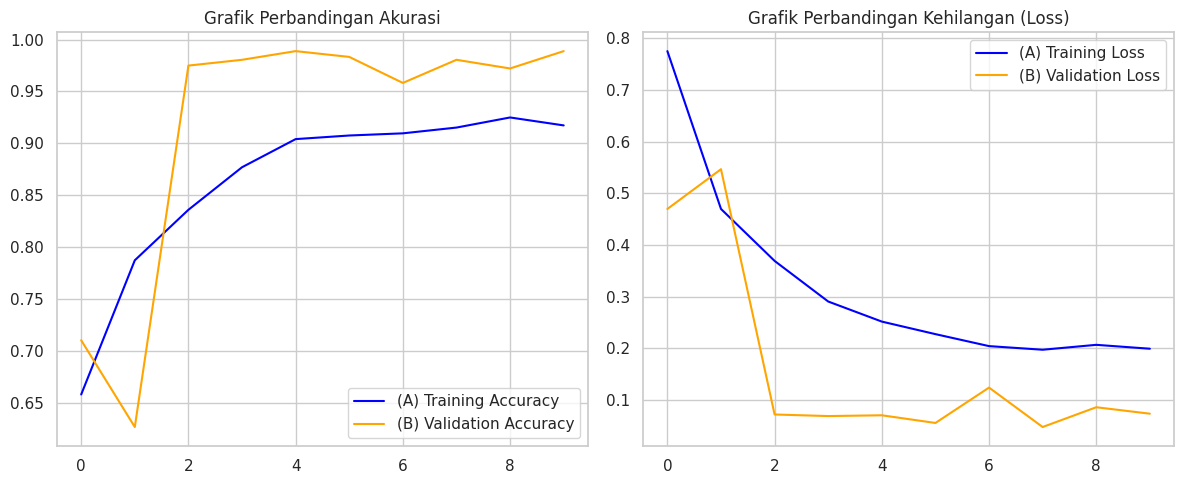


--- Laporan Klasifikasi Akhir ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 384ms/step
              precision    recall  f1-score   support

   Anorganik       0.99      0.99      0.99       202
     Organik       0.98      0.99      0.98       157

    accuracy                           0.99       359
   macro avg       0.99      0.99      0.99       359
weighted avg       0.99      0.99      0.99       359



In [14]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report

# 1. Membangun Arsitektur Model (Otak AI)
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax') # Pastikan 2 kelas: Organik & Anorganik
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 2. Eksekusi A/B Testing (Proses Training)
print("\n--- Memulai A/B Testing (Analisis Performa Latih vs Validasi) ---")
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# 3. Visualisasi Hasil A/B Testing
plt.figure(figsize=(12, 5))

# Perbandingan Akurasi (A vs B)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='(A) Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='(B) Validation Accuracy', color='orange')
plt.title('Grafik Perbandingan Akurasi')
plt.legend()

# Perbandingan Loss (A vs B)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='(A) Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='(B) Validation Loss', color='orange')
plt.title('Grafik Perbandingan Kehilangan (Loss)')
plt.legend()

plt.tight_layout()
plt.show()

# 4. Laporan Performa Akhir
print("\n--- Laporan Klasifikasi Akhir ---")
validation_generator.reset()
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)

print(classification_report(
    validation_generator.classes,
    y_pred,
    target_names=list(train_generator.class_indices.keys())
))

Pada tahap A/B Testing ini, model *Convolutional Neural Network* (CNN) digunakan untuk melakukan klasifikasi gambar sampah ke dalam dua kategori, yaitu `Organik` dan `Anorganik`. Model dilatih menggunakan data hasil *feature engineering* sebelumnya dan dievaluasi selama **10 epoch** untuk melihat perkembangan performa model dari sisi akurasi maupun nilai kehilangan (*loss*).

Berdasarkan grafik **Perbandingan Akurasi** di sebelah kiri, terlihat bahwa akurasi data latih (*training accuracy*) meningkat secara konsisten dari sekitar **66%** pada epoch pertama hingga mencapai sekitar **91–92%** pada epoch terakhir. Sementara itu, akurasi validasi (*validation accuracy*) mengalami peningkatan yang jauh lebih cepat, dimulai dari sekitar **71%**, sempat turun pada epoch kedua, kemudian melonjak drastis hingga berada di kisaran **97–99%** mulai epoch ketiga sampai akhir pelatihan. Pada epoch terakhir, akurasi validasi mencapai hampir **99%**, yang menunjukkan bahwa model mampu mengenali pola klasifikasi dengan sangat baik pada data validasi.

Pada grafik **Perbandingan Kehilangan (Loss)** di sebelah kanan, terlihat bahwa nilai *training loss* menurun secara stabil dari sekitar **0,78** menjadi sekitar **0,20** pada akhir pelatihan. Hal ini menunjukkan bahwa model semakin baik dalam meminimalkan kesalahan prediksi selama proses belajar. Di sisi lain, *validation loss* juga mengalami penurunan yang sangat signifikan dari sekitar **0,47** menjadi di bawah **0,10**, meskipun terdapat sedikit fluktuasi pada beberapa epoch. Namun secara keseluruhan, tren penurunan loss pada data validasi menunjukkan bahwa model memiliki kemampuan generalisasi yang baik dan tidak menunjukkan gejala overfitting yang serius.

Hasil evaluasi akhir pada **359 data validasi** menunjukkan performa model yang sangat tinggi. Berdasarkan laporan klasifikasi, kategori `Anorganik` memperoleh nilai *precision*, *recall*, dan *F1-score* masing-masing sebesar **0,99** dengan total **202 sampel**. Sementara itu, kategori `Organik` memperoleh *precision* sebesar **0,98**, *recall* sebesar **0,99**, dan *F1-score* sebesar **0,98** pada **157 sampel**. Secara keseluruhan, model berhasil mencapai **akurasi total sebesar 99%** dengan nilai *macro average* dan *weighted average* yang juga berada pada angka **0,99**.

Dari hasil tersebut dapat disimpulkan bahwa model CNN yang digunakan telah mampu melakukan klasifikasi sampah Organik dan Anorganik dengan performa yang sangat baik dan seimbang pada kedua kelas. Tingginya nilai akurasi, precision, recall, dan F1-score menunjukkan bahwa model cukup andal dalam mengenali karakteristik visual kedua jenis sampah, sehingga layak digunakan sebagai baseline model untuk tahap pengembangan sistem klasifikasi sampah selanjutnya.


Save model

In [15]:
model.save('model_sampah_final.h5')

Pada tahap *save model*, kode digunakan untuk menyimpan model yang telah selesai dilatih ke dalam sebuah file dengan perintah `model.save('model_sampah_final.h5')`. Format `.h5` atau HDF5 dipilih sebagai format penyimpanan, yang memungkinkan seluruh komponen model tersimpan dalam satu file tunggal, mencakup arsitektur jaringan, bobot hasil pelatihan, konfigurasi optimizer, hingga status pelatihan terakhir. Hal ini memudahkan proses pemuatan ulang model di kemudian hari tanpa perlu membangun ulang arsitektur dari awal.

Namun, sistem memunculkan sebuah peringatan `WARNING:absl` yang menyatakan bahwa format HDF5 melalui `model.save()` kini dianggap sebagai format *legacy* atau usang. TensorFlow dan Keras merekomendasikan penggunaan format native Keras yang lebih modern, yaitu dengan ekstensi `.keras`, menggunakan perintah `model.save('my_model.keras')` atau `keras.saving.save_model(model, 'my_model.keras')`. Peringatan ini tidak menghentikan proses penyimpanan dan model tetap berhasil disimpan, namun sebaiknya diperhatikan untuk pengembangan ke depannya guna memastikan kompatibilitas dengan versi TensorFlow dan Keras yang lebih baru. Perpindahan ke format `.keras` juga disarankan karena menawarkan dukungan yang lebih baik terhadap fitur-fitur terbaru Keras serta proses serialisasi yang lebih andal.